In [1]:
import os
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent
os.chdir(project_root)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

Импортируем данные

P.S.: Перед запуском выполнить python -m lab4.src.utils.download_data

In [2]:
!python -m spacy download en_core_web_sm

from sklearn.model_selection import train_test_split
from lab4.src.text_processor import TextDataProcessor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from lab4.config import Config
config = Config()

train_path = Path(config.target_dir) / "train.csv"

df = pd.read_csv(train_path).set_index("id")
X = df["comment_text"]
y = df.drop(columns=["comment_text"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Пайплайн обработки текста
prep = Pipeline([
   # Чистка текста
    ('cleaner', TextDataProcessor()),
   #  Векторизация (TF-IDF)
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2))),
])

# очистка + tfidf
X_train_features = prep.fit_transform(X_train)  # train+eval для X_train (обучаем и сохраняем веса tf-idf)
X_test_features = prep.transform(X_test) # eval для X_test (применяем ранее обученные веса tf-idf на тестовую выборку)

# Про tf-idf: https://habr.com/ru/companies/otus/articles/755772/

Checked 1 package in 2ms
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


Cleaning text: 100%|██████████| 23936/23936 [00:30<00:00, 794.73it/s]


Пороги модели

In [3]:
# Пороги настраиваем в ручную (без оптимизации)
THRESHOLDS = {
    "toxic": 0.30,
    "severe_toxic": 0.15,
    "obscene": 0.30,
    "threat": 0.10,
    "insult": 0.25,
    "identity_hate": 0.15,
}

1) Настраиваем pipeline для Логистической регрессии (LogisticRegression)

In [ ]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression


# В LogisticRegression зашита сигмоида; оптимизатор - "lbfgs". На иницилизации веса произвольные 
# Solver выбрали по рекомендациям из интернета (быстрее для классификации)
clf_lr = MultiOutputClassifier(
       LogisticRegression(class_weight="balanced", solver="liblinear")
   )


# Считаем всё необходимое для метрик (вероятности)
def compute_predictions(clf, X_features, y_test, thresholds=None) -> dict:
    
    class_names = list(y_test.columns)
    n_classes = len(class_names)

	 # Конкретная итоговая метрика строки - 0 или 1 по каждому классу
    y_pred = clf.predict(X_features)
    
    # Вероятность между [0,1] по принадлежности строки к определенному классу
    raw = clf.predict_proba(X_features)
    proba = np.zeros((X_features.shape[0], n_classes))
    for i in range(n_classes):
        proba[:, i] = raw[i][:, 1]

	 # Пороги
    if thresholds is None:
        thr = np.full(n_classes, 0.5)
    else:
        thr = np.array([thresholds[name] for name in class_names])

    y_pred = (proba >= thr).astype(int)

    return {
        "class_names": class_names, "n_classes": n_classes,
        "y_true": y_test.values, "y_pred": y_pred, "proba": proba,
        "thresholds": thr,
    }

Обучение

In [5]:
clf_lr.fit(X_train_features, y_train)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.A :term:`predict_proba` method will be exposed only if `estimator` implementsit.,LogisticRegre...r='liblinear')
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights invers

In [6]:
from sklearn.utils.validation import check_is_fitted

check_is_fitted(clf_lr) 

preds_lr = compute_predictions(clf_lr, X_test_features, y_test, THRESHOLDS)

Вывод метрик

In [7]:
from sklearn.metrics import (
   roc_auc_score, roc_curve,
   average_precision_score, precision_recall_curve,
   classification_report, multilabel_confusion_matrix,
)

# Подбираем параметры под каждый класс

def evaluate_multilabel_model(preds: dict) -> dict:

	class_names = preds["class_names"]
	n_classes = preds["n_classes"]
	y_true = preds["y_true"]
	y_pred = preds["y_pred"]
	proba = preds["proba"] 
  
   # Считаем ROC-AUC и PR-AUC
	roc_scores, pr_scores = {}, {}
	for i, name in enumerate(class_names):
		if len(np.unique(y_true[:, i])) < 2:
			roc_scores[name] = np.nan
			pr_scores[name] = np.nan
			continue
		roc_scores[name] = roc_auc_score(y_true[:, i], proba[:, i])
		pr_scores[name] = average_precision_score(y_true[:, i], proba[:, i])

	mean_roc = np.nanmean(list(roc_scores.values()))
	mean_pr = np.nanmean(list(pr_scores.values()))
    
   # Графики ROC-AUC
	plt.figure(figsize=(8, 6))
	for i, name in enumerate(class_names):
		if np.isnan(roc_scores[name]):
			continue
		fpr, tpr, _ = roc_curve(y_true[:, i], proba[:, i])
		plt.plot(fpr, tpr, label=f"{name} (AUC={roc_scores[name]:.3f})")
	plt.plot([0, 1], [0, 1], "k--", alpha=0.4)      # линия случайного угадывания
	plt.xlabel("FPR")
	plt.ylabel("TPR")
	plt.title(f"ROC-кривые по меткам | средний ROC-AUC = {mean_roc:.3f}")
	plt.legend(loc="lower left", fontsize=9)
	plt.tight_layout()
	plt.show()

   # Графики PR-AUC
	plt.figure(figsize=(8, 6))
	for i, name in enumerate(class_names):
		if np.isnan(pr_scores[name]):
			continue
		prec, rec, _ = precision_recall_curve(y_true[:, i], proba[:, i])
		plt.plot(rec, prec, label=f"{name} (AP={pr_scores[name]:.3f})")
	plt.xlabel("Recall")
	plt.ylabel("Precision")
	plt.title(f"Precision-Recall кривые | средний PR-AUC = {mean_pr:.3f}")
	plt.legend(loc="lower left", fontsize=9)
	plt.tight_layout()
	plt.show()

   # Графики ROC-AUC vs PR-AUC
	x = np.arange(n_classes)
	w = 0.35
	plt.figure(figsize=(9, 5))
	plt.bar(x - w/2, [roc_scores[n] for n in class_names], w, label="ROC-AUC")
	plt.bar(x + w/2, [pr_scores[n] for n in class_names], w, label="PR-AUC")
	plt.xticks(x, class_names, rotation=30, ha="right")
	plt.ylim(0, 1)
	plt.ylabel("Значение")
	plt.title("ROC-AUC и PR-AUC по каждой метке")
	plt.legend()
	plt.tight_layout()
	plt.show()

	# Сonfusion_matrix
	mcm = multilabel_confusion_matrix(y_true, y_pred)
	fig, axes = plt.subplots(2, 3, figsize=(12, 8))
	for ax, name, cm in zip(axes.ravel(), class_names, mcm):
		ax.imshow(cm, cmap="Blues")
		ax.set_title(name)
		ax.set_xticks([0, 1]); ax.set_xticklabels(["a(x)=0", "a(x)=1"])
		ax.set_yticks([0, 1]); ax.set_yticklabels(["y=0", "y=1"])
		for r in range(2):
			for c in range(2):
					ax.text(c, r, cm[r, c], ha="center", va="center",
							color="black", fontsize=12)
	fig.suptitle("Матрицы ошибок по меткам (TN FP / FN TP)")
	plt.tight_layout()
	plt.show()

	# precision / recall / f1
	print("\n=== Отчёт по меткам ===")
	for i, name in enumerate(class_names):
		print(f"\n--- {name} ---")
		print(classification_report(y_true[:, i], y_pred[:, i], zero_division=0))

	return {
		"roc_auc": roc_scores, "pr_auc": pr_scores,
		"mean_roc_auc": mean_roc, "mean_pr_auc": mean_pr,
	}

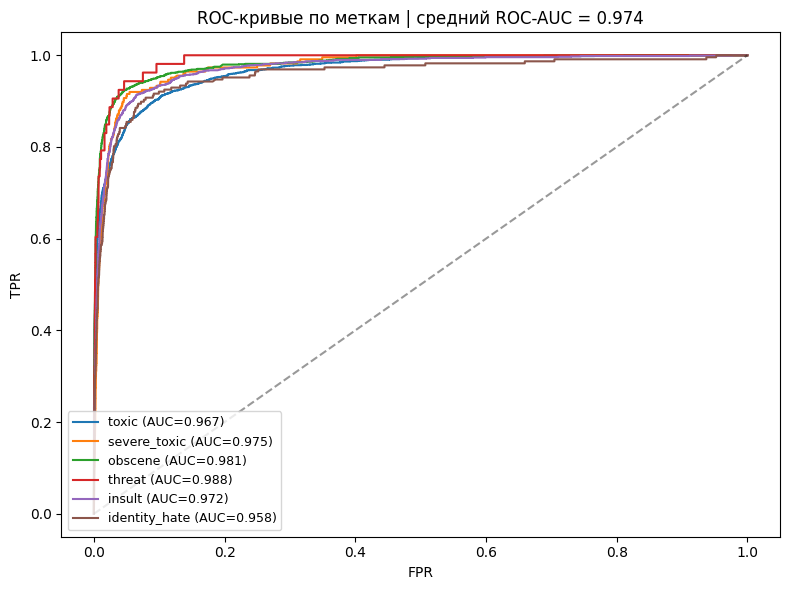

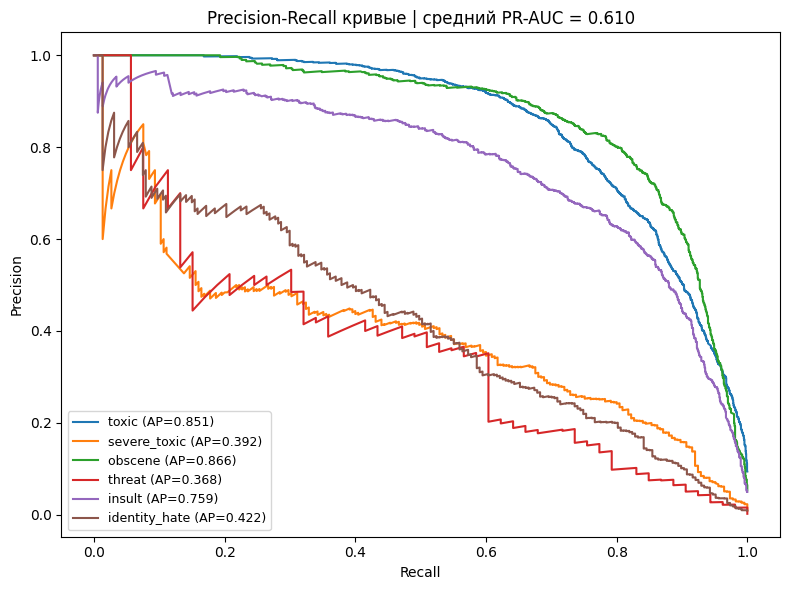

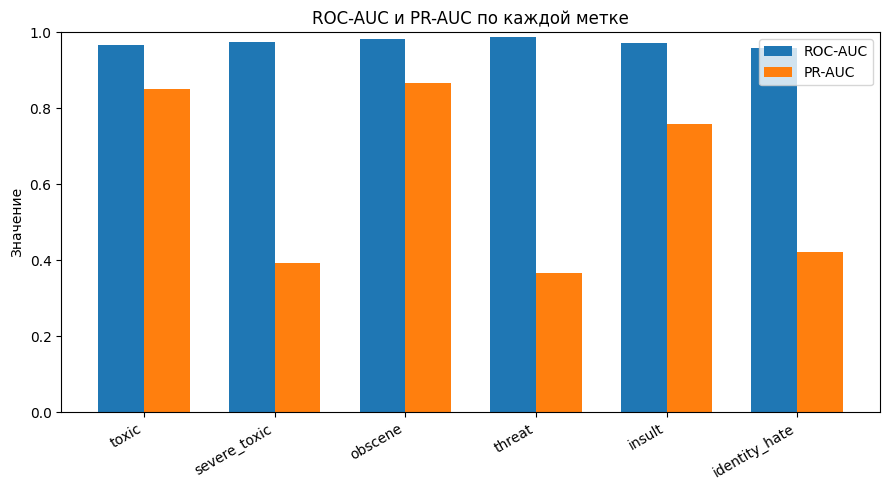

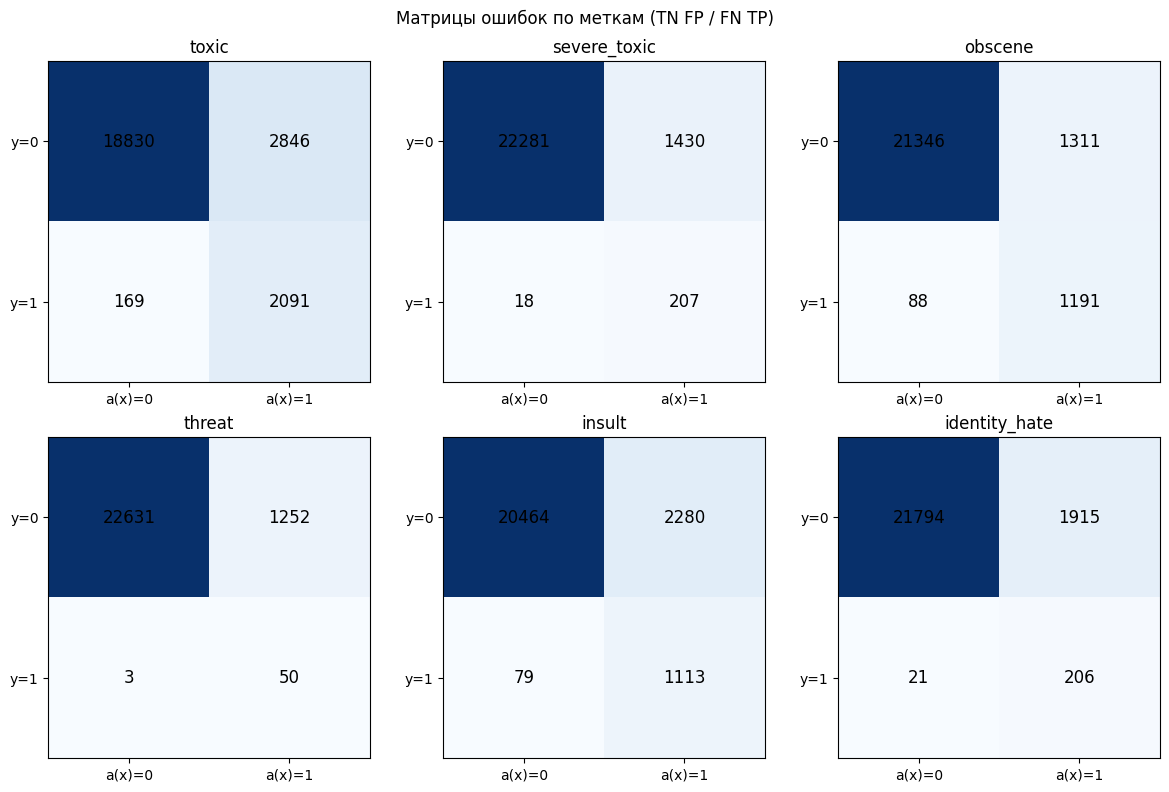


=== Отчёт по меткам ===

--- toxic ---
              precision    recall  f1-score   support

           0       0.99      0.87      0.93     21676
           1       0.42      0.93      0.58      2260

    accuracy                           0.87     23936
   macro avg       0.71      0.90      0.75     23936
weighted avg       0.94      0.87      0.89     23936


--- severe_toxic ---
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     23711
           1       0.13      0.92      0.22       225

    accuracy                           0.94     23936
   macro avg       0.56      0.93      0.60     23936
weighted avg       0.99      0.94      0.96     23936


--- obscene ---
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     22657
           1       0.48      0.93      0.63      1279

    accuracy                           0.94     23936
   macro avg       0.74      0.94      0.80     2

In [8]:
metrics = evaluate_multilabel_model(preds_lr)

print(f"Средний ROC-AUC: {metrics['mean_roc_auc']:.4f}")
print(f"Средний PR-AUC: {metrics['mean_pr_auc']:.4f}")

print("\nROC-AUC по меткам:")
for label, score in metrics["roc_auc"].items():
    print(f"  {label:15}: {score:.4f}")

print("\nPR-AUC по меткам:")
for label, score in metrics["pr_auc"].items():
    print(f"  {label:15}: {score:.4f}")

Вывод FN и FP

In [9]:
def show_errors(preds: dict, X_test, label_name, n_examples=10):
    
    class_names = preds["class_names"]
    idx = class_names.index(label_name)

    y_true = preds["y_true"][:, idx]
    y_pred = preds["y_pred"][:, idx]
    proba = preds["proba"][:, idx]

    X_arr = np.array(X_test)  # исходные тексты

    fn_mask = (y_true == 1) & (y_pred == 0) # FN
    fp_mask = (y_true == 0) & (y_pred == 1) # FP

    fn_idx = np.where(fn_mask)[0]
    fp_idx = np.where(fp_mask)[0]

    # Сортировка
    fn_idx = fn_idx[np.argsort(proba[fn_idx])]
    fp_idx = fp_idx[np.argsort(-proba[fp_idx])]

    print(f"Метка: {label_name} | FN: {len(fn_idx)}  FP: {len(fp_idx)}")

    print(f"\n--- FN, топ {n_examples} ---")
    for i in fn_idx[:n_examples]:
        print(f"[p={proba[i]:.2f}] {str(X_arr[i])[:200]}")

    print(f"\n--- FP, топ {n_examples} ---")
    for i in fp_idx[:n_examples]:
        print(f"[p={proba[i]:.2f}] {str(X_arr[i])[:200]}")

    return {"fn_indices": fn_idx, "fp_indices": fp_idx}

In [10]:
show_errors(preds_lr, X_test, "toxic", n_examples=10)
# show_errors(preds_lr, X_test"severe_toxic", n_examples=10)
# show_errors(preds_lr, X_test, "obscene", n_examples=10)
# show_errors(preds_lr, X_test, "threat", n_examples=10)
# show_errors(preds_lr, X_test, "insult", n_examples=10)
# show_errors(preds_lr, X_test, "identity_hate", n_examples=10)

Метка: toxic | FN: 169  FP: 2846

--- FN, топ 10 ---
[p=0.00] "STOP DELETING MY ADDITION!  You, Muboshgu/Mephistophelian say:

Please do not use talk pages ... for general discussion of the topic. They are
for discussion related to improving the article. They ar
[p=0.02] ":::""WP:DTTR is an essay."" I didn't say anything about WP:DTTR. I pointed out what is a practice according to members of the community, something I would not merely dismiss out of hand as you seem t
[p=0.02] Your comments on WP:AN/I 

Tomer, while I can understand your frustration with some of Witkacy's behaviour, your comments on the administrator's noticeboard are inappropriate.

I would encourage you t
[p=0.02] "

fuck u communist bastards!!!! if u lik the sunflkower on this page go blow urself.  It has all the sections clearly labeled and it is easy to read.  One small thing would maybe be to have less sect
[p=0.03] ... 

Hi, I have no idea what you are babbling about...
[p=0.04] "
Without playing your silly game

{'fn_indices': array([ 6129,  4420,  5108, 22479,  4757, 17441, 23469, 15377,  8154,
         9174,  2223,  2071,  5157,  6740, 18488, 21514, 17582, 19972,
        16977, 22602,  3345, 18253, 20400,  3025,  3275,  6008, 10226,
        13340, 11956, 17572, 23701, 10529, 23918, 15606,  8620,  2480,
        22408, 13999, 18165, 22930,  3239, 22133,  7587,  8389,  4395,
        12766, 10278, 11012, 21089, 16980, 22951, 18585, 16210,  7771,
         4599,  6433, 18872,  9117, 16362,  3595, 21502,  7489, 12984,
        22458,  1122,  8030, 19352, 11846, 13753, 11180, 10932, 10941,
        22986, 22659, 15564, 10630, 16659, 22558, 18472, 19513, 18395,
        15445, 22914,  5600,   344,  8605,  4466,  8377, 15945, 16225,
        10012,  5871,  3457, 20067,  1994,  5753, 10441, 22939, 13326,
         7460, 14071,  3965, 12495, 22825,  2215, 14818,  8387,  6855,
         5974, 19231, 13823,   907, 23073, 22754, 16413,  3947, 13485,
        10403,  9365,  7233,  2165, 10009, 10388,  6186,   661,

2) Настраиваем pipeline для RandomForest

In [11]:
from sklearn.ensemble import RandomForestClassifier

clf_rf = MultiOutputClassifier(
       RandomForestClassifier(
          n_estimators=75, 
          max_depth=30, 
          min_samples_leaf=5, 
         #  class_weight="balanced_subsample", 
          random_state=42,
          n_jobs=-2,
          ),
       n_jobs=-2,
       )

Обучение

In [12]:
clf_rf.fit(X_train_features, y_train)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.A :term:`predict_proba` method will be exposed only if `estimator` implementsit.,RandomForestC...ndom_state=42)
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",-2
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",75
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the follow

In [13]:
from sklearn.utils.validation import check_is_fitted

check_is_fitted(clf_rf) 

preds_rf = compute_predictions(clf_rf, X_test_features, y_test, THRESHOLDS)

Вывод метрик

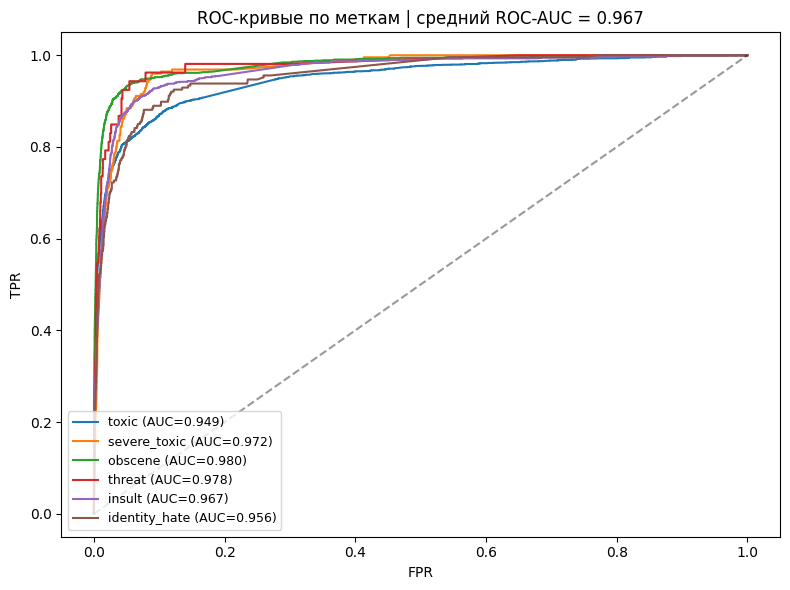

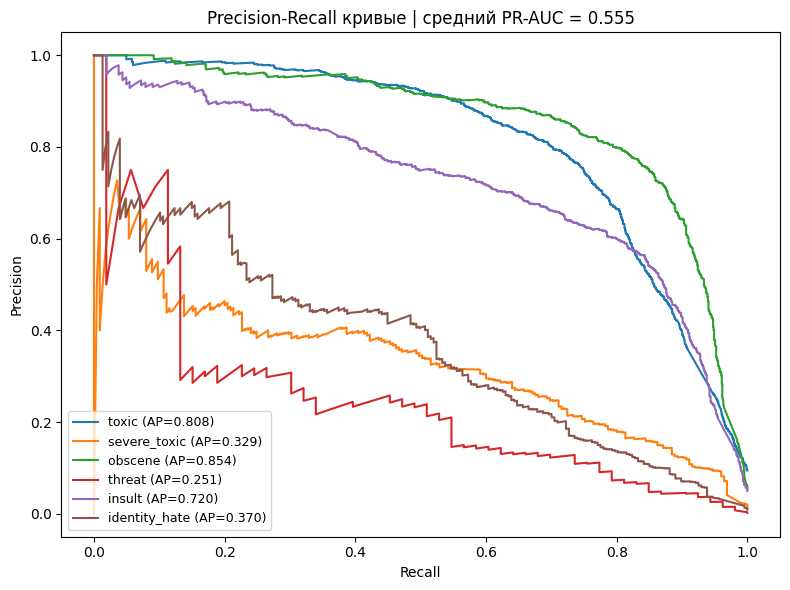

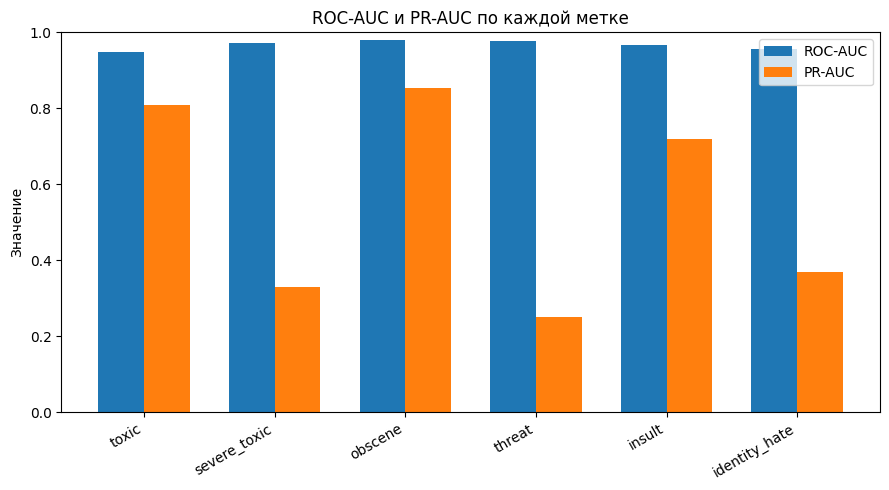

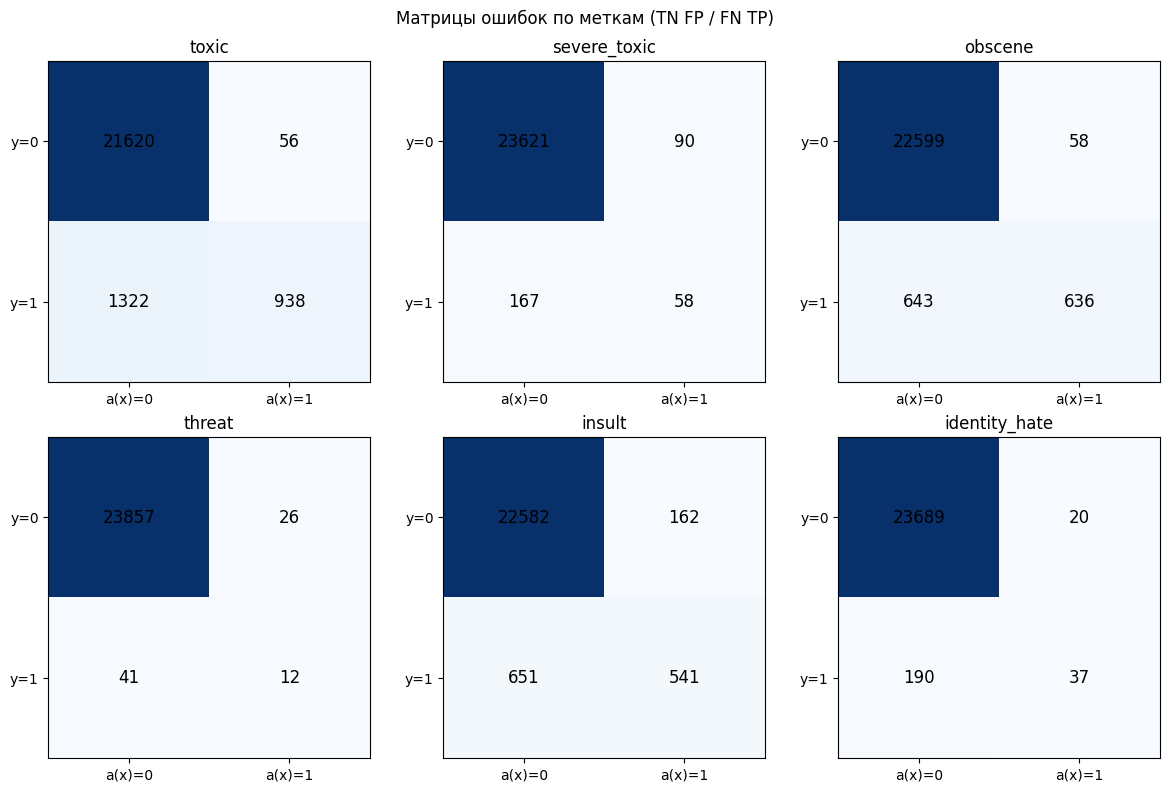


=== Отчёт по меткам ===

--- toxic ---
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     21676
           1       0.94      0.42      0.58      2260

    accuracy                           0.94     23936
   macro avg       0.94      0.71      0.77     23936
weighted avg       0.94      0.94      0.93     23936


--- severe_toxic ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     23711
           1       0.39      0.26      0.31       225

    accuracy                           0.99     23936
   macro avg       0.69      0.63      0.65     23936
weighted avg       0.99      0.99      0.99     23936


--- obscene ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     22657
           1       0.92      0.50      0.64      1279

    accuracy                           0.97     23936
   macro avg       0.94      0.75      0.81     2

In [14]:
metrics = evaluate_multilabel_model(preds_rf)

print(f"Средний ROC-AUC: {metrics['mean_roc_auc']:.4f}")
print(f"Средний PR-AUC: {metrics['mean_pr_auc']:.4f}")

print("\nROC-AUC по меткам:")
for label, score in metrics["roc_auc"].items():
    print(f"  {label:15}: {score:.4f}")

print("\nPR-AUC по меткам:")
for label, score in metrics["pr_auc"].items():
    print(f"  {label:15}: {score:.4f}")

Вывод ошибок

In [15]:
show_errors(preds_rf, X_test, "toxic", n_examples=10)
# show_errors(preds_rf, X_test, "severe_toxic", n_examples=10)
# show_errors(preds_rf, X_test, "obscene", n_examples=10)
# show_errors(preds_rf, X_test, "threat", n_examples=10)
# show_errors(preds_rf, X_test, "insult", n_examples=10)
# show_errors(preds_rf, X_test, "identity_hate", n_examples=10)

Метка: toxic | FN: 1322  FP: 56

--- FN, топ 10 ---
[p=0.03] "STOP DELETING MY ADDITION!  You, Muboshgu/Mephistophelian say:

Please do not use talk pages ... for general discussion of the topic. They are
for discussion related to improving the article. They ar
[p=0.04] "

Hi. It's from the same user who was changing the images before on similar articles. Not to mention that, both images are good resolutions, contrary to what the user says, which is why I don't see t
[p=0.04] "

  Are you fing kidding me? There are 30+ reliable sources listed in the pre-vandalism history of the page. This debate in this talk page has no importance and will not receive justice. I am making 
[p=0.05] "

THIS IS MY REPLY TO YOU THAT YOU HAVE DELETED ACTING AS A FASCIST FROM THE DISCUSSION ON NICOSIA PAGE:

Nicosia and discrimination against Greek contributors and the Greek character of the cityDear
[p=0.05] "You lying SOB==   
- ""I don't focus on single articles or wikiprojects; mostly I just tweak an ar

{'fn_indices': array([ 6129,  2223, 10226, ..., 10561, 17864,  8512], shape=(1322,)),
 'fp_indices': array([ 2961,  6468,  6429,  5507, 21760, 12205, 13258, 20539,  7639,
         5743,  4836, 14082, 17087,  3681,  9491,  5755, 22027,   899,
         5220,  5783, 16648, 13568, 20456, 10028,  8018, 23682, 15251,
         6134,  7524, 21620,  4888,  4078, 15555,  8102, 16027, 12749,
        13122,  9984, 14207,  7728, 15635, 20386,   760, 21593,  6035,
         3823,   999, 13617,  5428, 19625, 19332, 11320, 22308, 12963,
         6940, 17023])}

3) Настраиваем pipeline для Линейного SVM (LinearSVC)

In [16]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

clf_svm = MultiOutputClassifier(
    CalibratedClassifierCV(
        LinearSVC(
           class_weight="balanced", C=1.0, max_iter=5000
           ),
        method="sigmoid",
    ),
    n_jobs=-2,
)

Обучение

In [17]:
clf_svm.fit(X_train_features, y_train)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.A :term:`predict_proba` method will be exposed only if `estimator` implementsit.,CalibratedCla...ax_iter=5000))
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",-2
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercep

In [18]:
from sklearn.utils.validation import check_is_fitted

check_is_fitted(clf_svm) 

preds_svm = compute_predictions(clf_svm, X_test_features, y_test, THRESHOLDS)

Вывод метрик

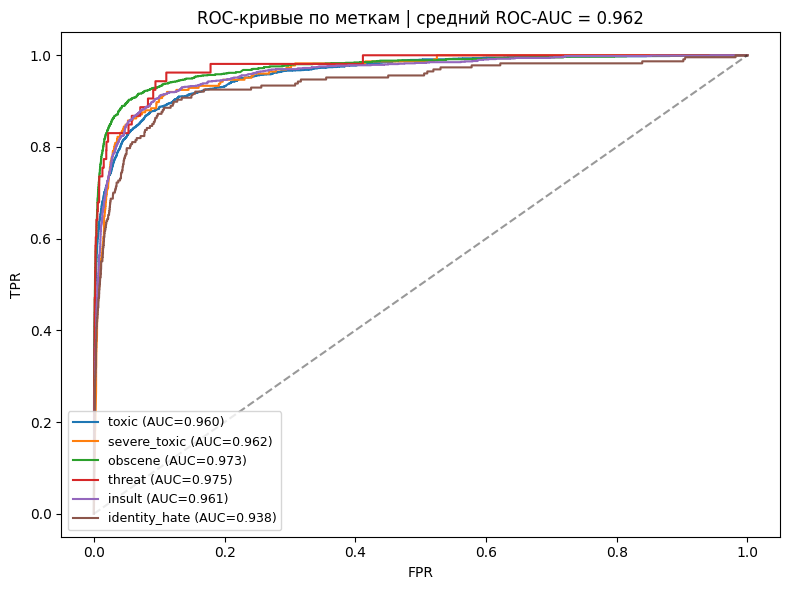

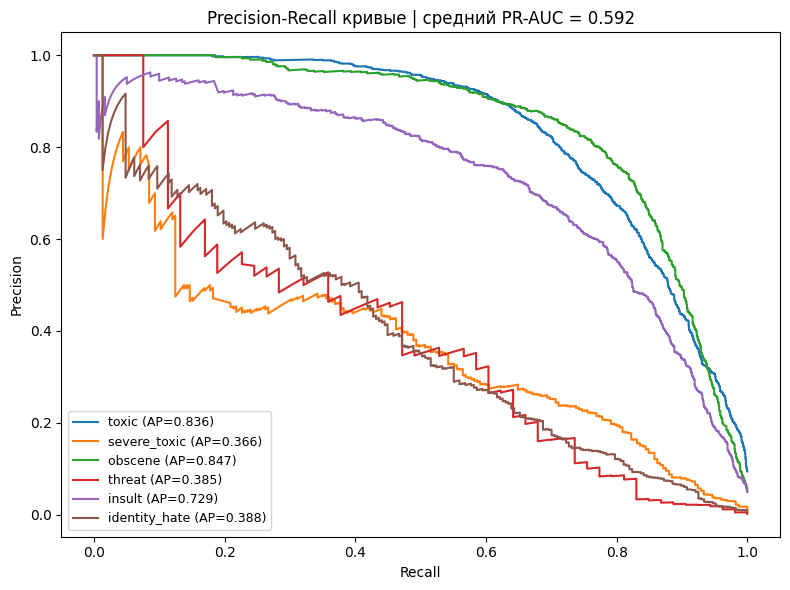

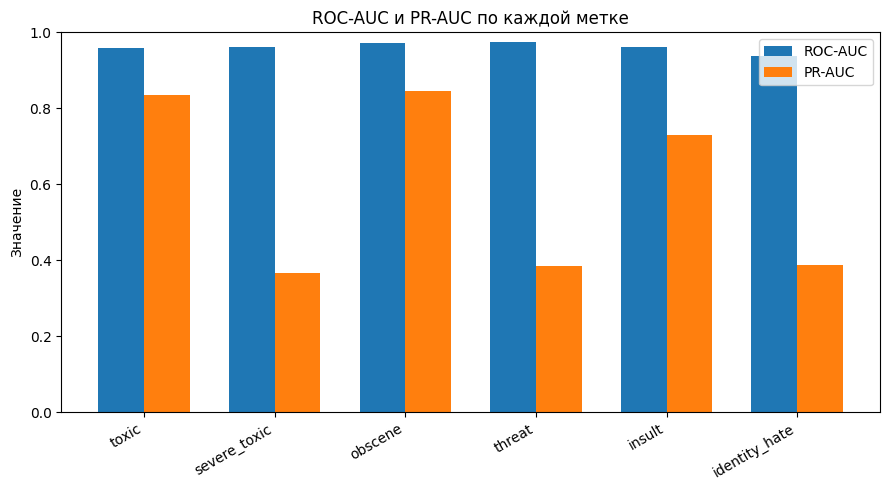

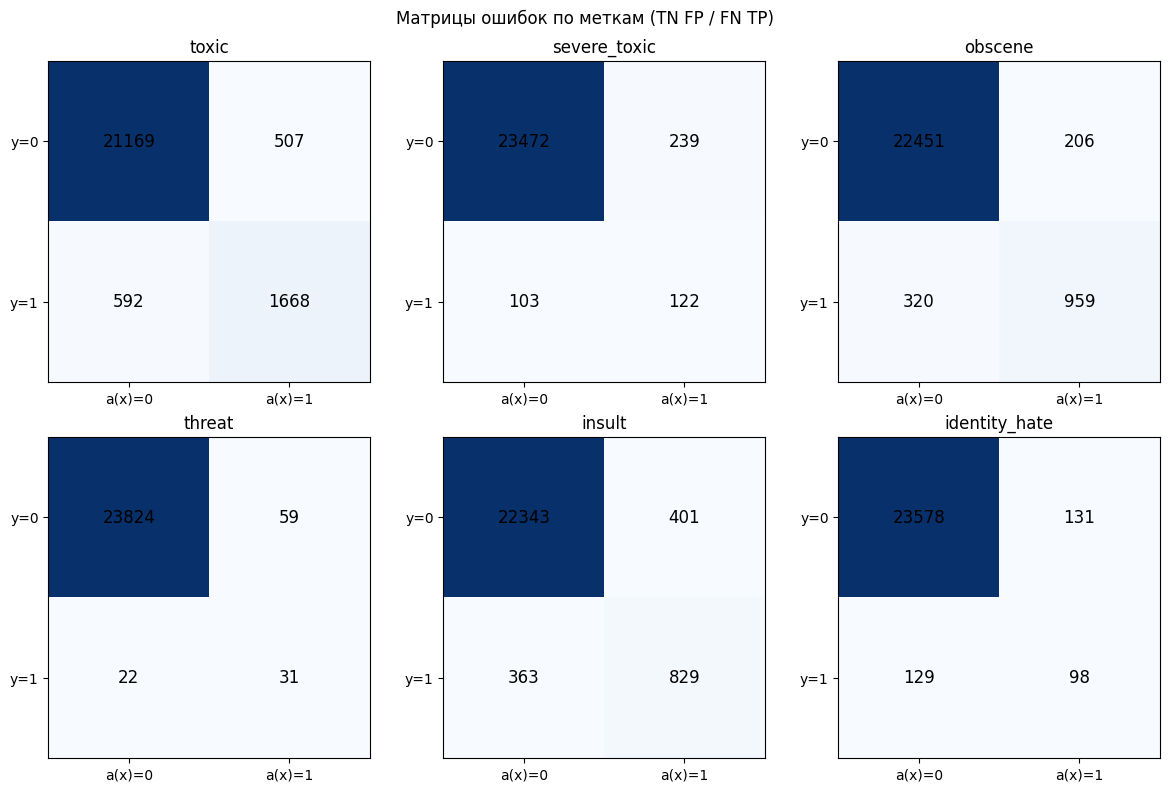


=== Отчёт по меткам ===

--- toxic ---
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     21676
           1       0.77      0.74      0.75      2260

    accuracy                           0.95     23936
   macro avg       0.87      0.86      0.86     23936
weighted avg       0.95      0.95      0.95     23936


--- severe_toxic ---
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     23711
           1       0.34      0.54      0.42       225

    accuracy                           0.99     23936
   macro avg       0.67      0.77      0.70     23936
weighted avg       0.99      0.99      0.99     23936


--- obscene ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     22657
           1       0.82      0.75      0.78      1279

    accuracy                           0.98     23936
   macro avg       0.90      0.87      0.89     2

In [19]:
metrics = evaluate_multilabel_model(preds_svm,)

print(f"Средний ROC-AUC: {metrics['mean_roc_auc']:.4f}")
print(f"Средний PR-AUC: {metrics['mean_pr_auc']:.4f}")

print("\nROC-AUC по меткам:")
for label, score in metrics["roc_auc"].items():
    print(f"  {label:15}: {score:.4f}")

print("\nPR-AUC по меткам:")
for label, score in metrics["pr_auc"].items():
    print(f"  {label:15}: {score:.4f}")

Вывод ошибок

In [20]:
show_errors(preds_svm, X_test, "toxic", n_examples=10)
# show_errors(pipeline_svm, X_test, "severe_toxic", n_examples=10)
# show_errors(pipeline_svm, X_test, "obscene", n_examples=10)
# show_errors(pipeline_svm, X_test, "threat", n_examples=10)
# show_errors(pipeline_svm, X_test, "insult", n_examples=10)
# show_errors(pipeline_svm, X_test, "identity_hate", n_examples=10)

Метка: toxic | FN: 592  FP: 507

--- FN, топ 10 ---
[p=0.00] "STOP DELETING MY ADDITION!  You, Muboshgu/Mephistophelian say:

Please do not use talk pages ... for general discussion of the topic. They are
for discussion related to improving the article. They ar
[p=0.00] ":::""WP:DTTR is an essay."" I didn't say anything about WP:DTTR. I pointed out what is a practice according to members of the community, something I would not merely dismiss out of hand as you seem t
[p=0.00] Your comments on WP:AN/I 

Tomer, while I can understand your frustration with some of Witkacy's behaviour, your comments on the administrator's noticeboard are inappropriate.

I would encourage you t
[p=0.00] "
 Wikipedia is just the latest casualty to ""O'Sullivan's Law""; and the double-standards and oily patrician-like attitudes of some admins are blatant. I expect the whole place to be thoroughly dhimm
[p=0.00] "
Without playing your silly game no more, I'll just skip to the point and suggest a new sentence:


{'fn_indices': array([ 6129,  4420,  5108,  8154, 17441, 23701, 22479, 19972, 16977,
        18165,  2223,  3345, 16362, 17572,  4757, 21514, 22133, 19513,
        12766, 10529, 18488, 21502, 20400, 23469,  4599, 11012, 10278,
         9174,  5157, 11956, 18253,  4395, 19352,  7587, 17582,  7771,
        18872,  2071,  7016,  8389,  3239, 15606, 18395, 15445,  7460,
        10388, 22408,  3275, 14818,  6433, 15377,  6008, 13326, 10630,
         2480, 10226, 22659,  1184, 10009, 21089, 10441,  4916, 16017,
         5871, 11180, 13340,  3595, 23918, 16210, 18472,  3025, 22602,
        22930, 16980,  8620,  2165, 15811, 14215,   661, 15945, 18211,
        22951,  9764, 22078,  6614, 13753,  3947,  1669, 12977, 22558,
        22521, 14071, 17113,   344,  7489, 11846, 12984, 19231,  9977,
         8377, 23073, 10356, 16659, 13887, 13999,  3965,  7233, 20351,
        22939,   907, 22458, 13823,  6740,  2215, 10941,  1994, 21917,
         5600, 10403,  5259, 12777,  9365, 16083, 12495,  4466,